  # TOTVS 2025 Challenge - Análise Exploratória de Dados,
    ## Estrutura dos Dados,
    - **MRR**: Receita recorrente mensal dos últimos 12 meses,
    - **Clientes**: Informações cadastrais e histórico de contratação,
    - **NPS**: Avaliações de satisfação do cliente,
    - **Telemetria**: Dados de uso do sistema,
    - **Tickets**: Suporte e atendimento
    

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
   
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 1. Carregamento e Análise Inicial dos Dados

In [7]:
mrr_df = pd.read_csv('Challenge_TOTVS_2025_MassaDados_v1/mrr.csv', sep=';')
clientes_desde_df = pd.read_csv('Challenge_TOTVS_2025_MassaDados_v1/clientes_desde.csv', sep=';')
contratacoes_df = pd.read_csv('Challenge_TOTVS_2025_MassaDados_v1/contratacoes_ultimos_12_meses.csv', sep=';')
nps_relacional_df = pd.read_csv('Challenge_TOTVS_2025_MassaDados_v1/nps_relacional.csv', sep=';')

print("=== RESUMO DOS DATASETS ===")
print(f"MRR: {mrr_df.shape[0]} clientes")
print(f"Clientes desde: {clientes_desde_df.shape[0]} registros")
print(f"Contratações: {contratacoes_df.shape[0]} registros")
print(f"NPS Relacional: {nps_relacional_df.shape[0]} avaliações")

=== RESUMO DOS DATASETS ===
MRR: 7309 clientes
Clientes desde: 10615 registros
Contratações: 4314 registros
NPS Relacional: 14143 avaliações


## 2. Análise do MRR 


=== ANÁLISE DO MRR ===
Total de clientes com MRR: 7309
MRR Total: R$ 4,951,424.49
MRR Médio: R$ 677.44
MRR Mediano: R$ 348.29
MRR Máximo: R$ 43,148.58
MRR Mínimo: R$ 0.00


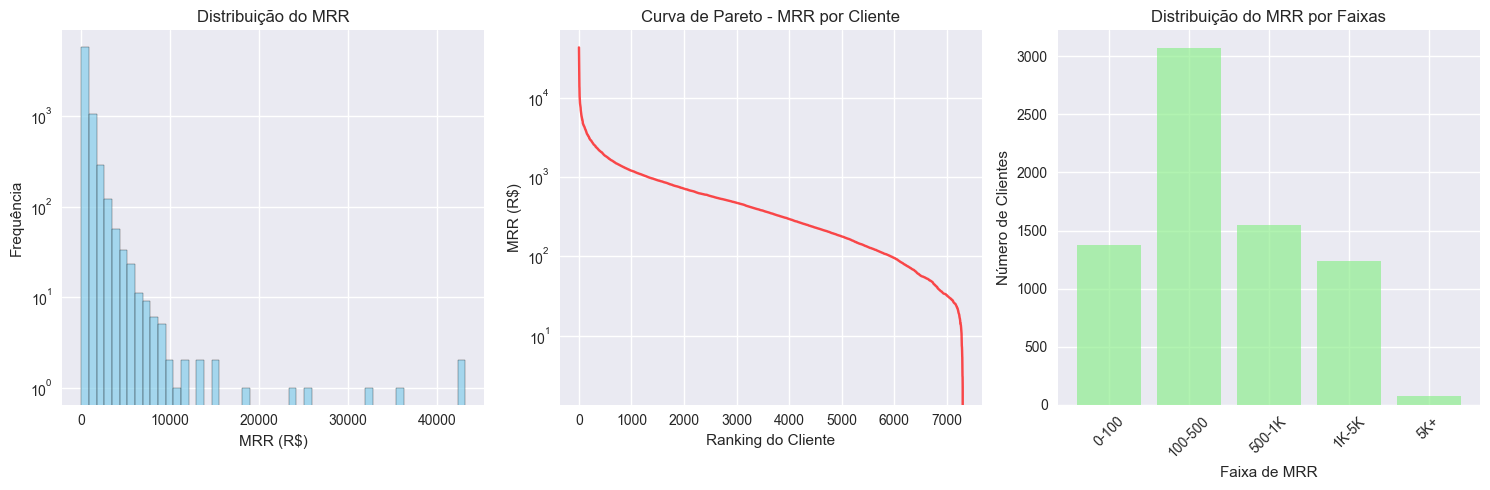

=== INSIGHTS DO MRR ===
Top 20% dos clientes representam 63.0% da receita
Clientes com MRR > R$ 1.000: 1314 (18.0%)


In [9]:
print("=== ANÁLISE DO MRR ===")
print(f"Total de clientes com MRR: {len(mrr_df)}")
print(f"MRR Total: R$ {mrr_df['MRR_12M'].sum():,.2f}")
print(f"MRR Médio: R$ {mrr_df['MRR_12M'].mean():,.2f}")
print(f"MRR Mediano: R$ {mrr_df['MRR_12M'].median():,.2f}")
print(f"MRR Máximo: R$ {mrr_df['MRR_12M'].max():,.2f}")
print(f"MRR Mínimo: R$ {mrr_df['MRR_12M'].min():,.2f}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(mrr_df['MRR_12M'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribuição do MRR')
plt.xlabel('MRR (R$)')
plt.ylabel('Frequência')
plt.yscale('log')

plt.subplot(1, 3, 2)
mrr_sorted = mrr_df['MRR_12M'].sort_values(ascending=False)
plt.plot(range(len(mrr_sorted)), mrr_sorted, color='red', alpha=0.7)
plt.title('Curva de Pareto - MRR por Cliente')
plt.xlabel('Ranking do Cliente')
plt.ylabel('MRR (R$)')
plt.yscale('log')

plt.subplot(1, 3, 3)
mrr_categories = pd.cut(mrr_df['MRR_12M'], 
                        bins=[0, 100, 500, 1000, 5000, float('inf')], 
                        labels=['0-100', '100-500', '500-1K', '1K-5K', '5K+'])
mrr_cat_counts = mrr_categories.value_counts().sort_index()
plt.bar(mrr_cat_counts.index, mrr_cat_counts.values, color='lightgreen', alpha=0.7)
plt.title('Distribuição do MRR por Faixas')
plt.xlabel('Faixa de MRR')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("=== INSIGHTS DO MRR ===")
print(f"Top 20% dos clientes representam {mrr_sorted.head(int(len(mrr_sorted)*0.2)).sum() / mrr_sorted.sum()*100:.1f}% da receita")
print(f"Clientes com MRR > R$ 1.000: {len(mrr_df[mrr_df['MRR_12M'] > 1000])} ({len(mrr_df[mrr_df['MRR_12M'] > 1000])/len(mrr_df)*100:.1f}%)")

## 3. Análise de Aquisição e Retenção de Clientes

=== ANÁLISE DE AQUISIÇÃO DE CLIENTES ===
Período de análise: 1971 - 2025
Total de clientes: 10615


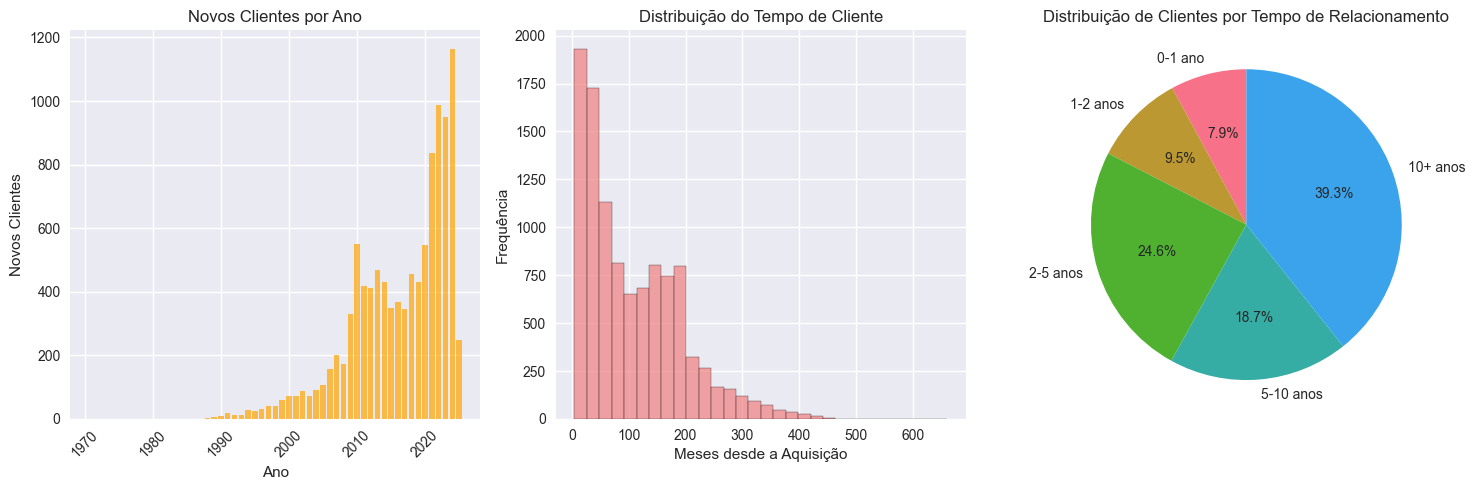

=== INSIGHTS DE AQUISIÇÃO ===
Clientes com mais de 5 anos: 6158 (58.0%)
Clientes novos (último ano): 1411 (13.3%)


In [10]:
clientes_desde_df['CLIENTE_DESDE'] = pd.to_datetime(clientes_desde_df['CLIENTE_DESDE'])
clientes_desde_df['ano_aquisicao'] = clientes_desde_df['CLIENTE_DESDE'].dt.year
clientes_desde_df['meses_desde_aquisicao'] = ((pd.Timestamp.now() - clientes_desde_df['CLIENTE_DESDE']).dt.days / 30).astype(int)

print("=== ANÁLISE DE AQUISIÇÃO DE CLIENTES ===")
print(f"Período de análise: {clientes_desde_df['ano_aquisicao'].min()} - {clientes_desde_df['ano_aquisicao'].max()}")
print(f"Total de clientes: {len(clientes_desde_df)}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
aquisicao_por_ano = clientes_desde_df['ano_aquisicao'].value_counts().sort_index()
plt.bar(aquisicao_por_ano.index, aquisicao_por_ano.values, color='orange', alpha=0.7)
plt.title('Novos Clientes por Ano')
plt.xlabel('Ano')
plt.ylabel('Novos Clientes')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
plt.hist(clientes_desde_df['meses_desde_aquisicao'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Distribuição do Tempo de Cliente')
plt.xlabel('Meses desde a Aquisição')
plt.ylabel('Frequência')

plt.subplot(1, 3, 3)
clientes_por_periodo = pd.cut(clientes_desde_df['meses_desde_aquisicao'], 
                               bins=[0, 12, 24, 60, 120, float('inf')], 
                               labels=['0-1 ano', '1-2 anos', '2-5 anos', '5-10 anos', '10+ anos'])
periodo_counts = clientes_por_periodo.value_counts().sort_index()
plt.pie(periodo_counts.values, labels=periodo_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição de Clientes por Tempo de Relacionamento')

plt.tight_layout()
plt.show()

print("=== INSIGHTS DE AQUISIÇÃO ===")
print(f"Clientes com mais de 5 anos: {len(clientes_desde_df[clientes_desde_df['meses_desde_aquisicao'] > 60])} ({len(clientes_desde_df[clientes_desde_df['meses_desde_aquisicao'] > 60])/len(clientes_desde_df)*100:.1f}%)")
print(f"Clientes novos (último ano): {len(clientes_desde_df[clientes_desde_df['ano_aquisicao'] >= 2024])} ({len(clientes_desde_df[clientes_desde_df['ano_aquisicao'] >= 2024])/len(clientes_desde_df)*100:.1f}%)")

## 4. Análise de Contratações e Valor do Cliente

=== ANÁLISE DE CONTRATAÇÕES ===
Total de clientes com contratações: 4314
Valor total das contratações: R$ 49,591,630.84
Valor médio por contratação: R$ 11,495.51
Número médio de contratações por cliente: 1.9


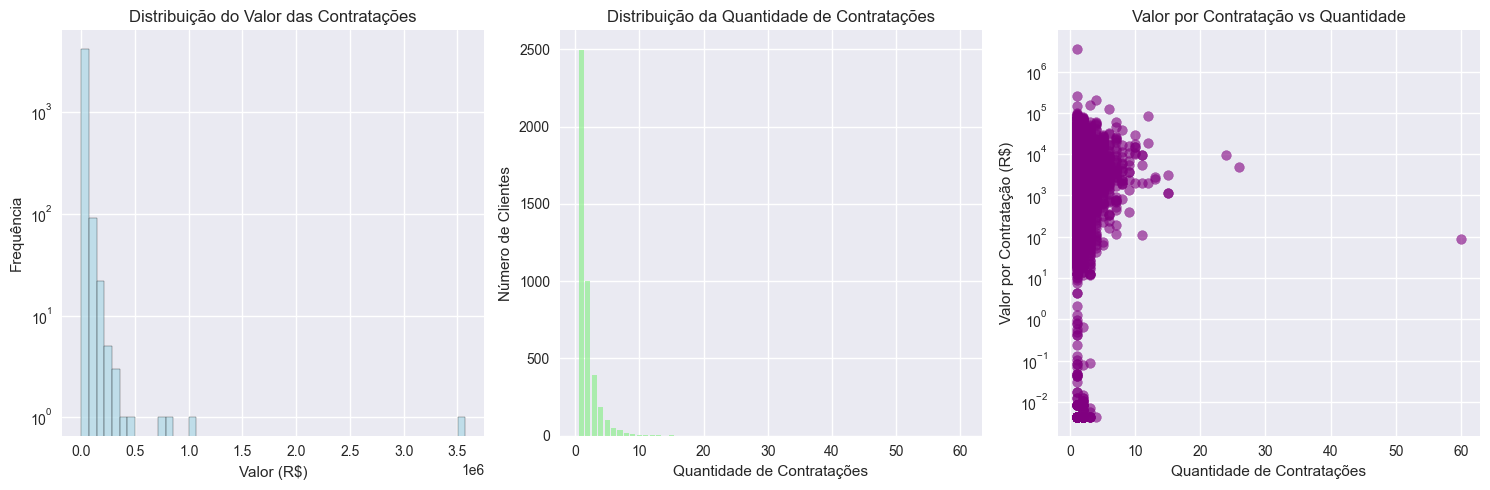

=== INSIGHTS DE CONTRATAÇÕES ===
Clientes com múltiplas contratações: 1816 (42.1%)
Top 10% em valor: R$ 27,182.43


In [15]:
print("=== ANÁLISE DE CONTRATAÇÕES ===")
print(f"Total de clientes com contratações: {len(contratacoes_df)}")

contratacoes_df['VLR_CONTRATACOES_12M'] = contratacoes_df['VLR_CONTRATACOES_12M'].str.replace(',', '.').astype(float)

print(f"Valor total das contratações: R$ {contratacoes_df['VLR_CONTRATACOES_12M'].sum():,.2f}")
print(f"Valor médio por contratação: R$ {contratacoes_df['VLR_CONTRATACOES_12M'].mean():,.2f}")
print(f"Número médio de contratações por cliente: {contratacoes_df['QTD_CONTRATACOES_12M'].mean():.1f}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(contratacoes_df['VLR_CONTRATACOES_12M'], bins=50, alpha=0.7, color='lightblue', edgecolor='black')
plt.title('Distribuição do Valor das Contratações')
plt.xlabel('Valor (R$)')
plt.ylabel('Frequência')
plt.yscale('log')

plt.subplot(1, 3, 2)
qtd_contratacoes = contratacoes_df['QTD_CONTRATACOES_12M'].value_counts().sort_index()
plt.bar(qtd_contratacoes.index, qtd_contratacoes.values, color='lightgreen', alpha=0.7)
plt.title('Distribuição da Quantidade de Contratações')
plt.xlabel('Quantidade de Contratações')
plt.ylabel('Número de Clientes')

plt.subplot(1, 3, 3)
contratacoes_df['valor_por_contratacao'] = contratacoes_df['VLR_CONTRATACOES_12M'] / contratacoes_df['QTD_CONTRATACOES_12M']
plt.scatter(contratacoes_df['QTD_CONTRATACOES_12M'], contratacoes_df['valor_por_contratacao'], alpha=0.6, color='purple')
plt.title('Valor por Contratação vs Quantidade')
plt.xlabel('Quantidade de Contratações')
plt.ylabel('Valor por Contratação (R$)')
plt.yscale('log')

plt.tight_layout()
plt.show()

print("=== INSIGHTS DE CONTRATAÇÕES ===")
print(f"Clientes com múltiplas contratações: {len(contratacoes_df[contratacoes_df['QTD_CONTRATACOES_12M'] > 1])} ({len(contratacoes_df[contratacoes_df['QTD_CONTRATACOES_12M'] > 1])/len(contratacoes_df)*100:.1f}%)")
print(f"Top 10% em valor: R$ {contratacoes_df['VLR_CONTRATACOES_12M'].quantile(0.9):,.2f}")

## 5. Análise de Satisfação do Cliente (NPS)

=== ANÁLISE DO NPS ===
Total de avaliações: 14143
Período: 2019-01 a 2025-03
NPS médio: 8.2
NPS mediano: 8.0


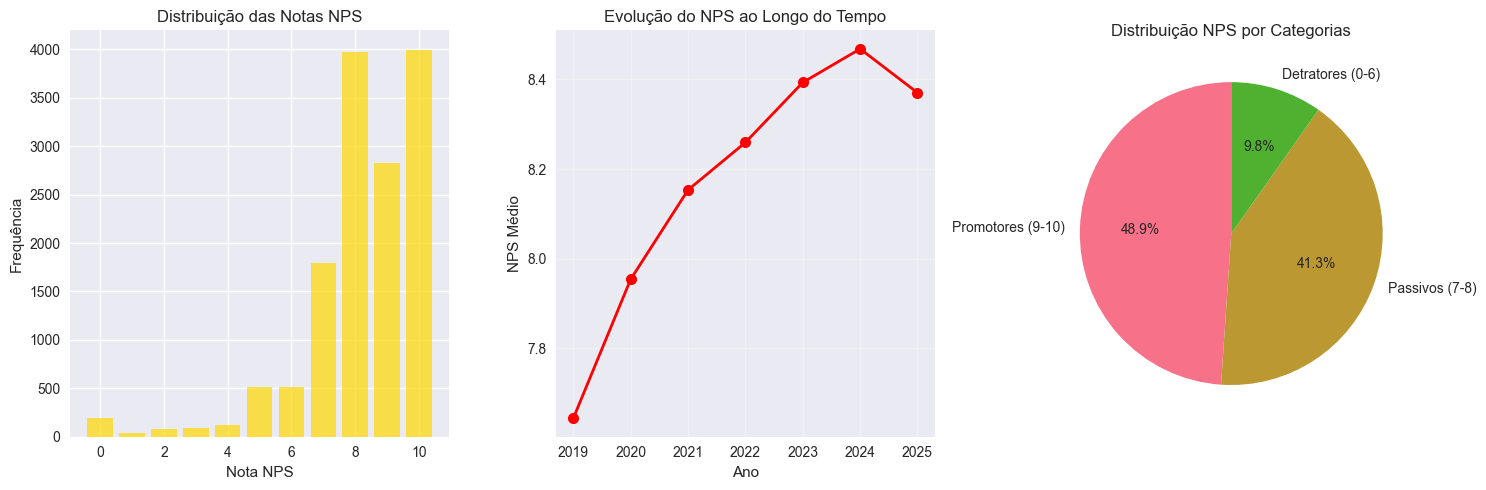

=== INSIGHTS DO NPS ===
NPS Score calculado: 37.3
Promotores: 6826 (48.3%)
Passivos: 5763 (40.7%)
Detratores: 1554 (11.0%)


In [16]:
nps_relacional_df['respondedAt'] = pd.to_datetime(nps_relacional_df['respondedAt'])
nps_relacional_df['ano'] = nps_relacional_df['respondedAt'].dt.year
nps_relacional_df['mes'] = nps_relacional_df['respondedAt'].dt.month

print("=== ANÁLISE DO NPS ===")
print(f"Total de avaliações: {len(nps_relacional_df)}")
print(f"Período: {nps_relacional_df['respondedAt'].min().strftime('%Y-%m')} a {nps_relacional_df['respondedAt'].max().strftime('%Y-%m')}")
print(f"NPS médio: {nps_relacional_df['resposta_NPS'].mean():.1f}")
print(f"NPS mediano: {nps_relacional_df['resposta_NPS'].median():.1f}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
nps_counts = nps_relacional_df['resposta_NPS'].value_counts().sort_index()
plt.bar(nps_counts.index, nps_counts.values, color='gold', alpha=0.7)
plt.title('Distribuição das Notas NPS')
plt.xlabel('Nota NPS')
plt.ylabel('Frequência')

plt.subplot(1, 3, 2)
nps_por_ano = nps_relacional_df.groupby('ano')['resposta_NPS'].mean()
plt.plot(nps_por_ano.index, nps_por_ano.values, marker='o', linewidth=2, markersize=8, color='red')
plt.title('Evolução do NPS ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('NPS Médio')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
nps_categorias = pd.cut(nps_relacional_df['resposta_NPS'], 
                        bins=[0, 6, 8, 10], 
                        labels=['Detratores (0-6)', 'Passivos (7-8)', 'Promotores (9-10)'])
nps_cat_counts = nps_categorias.value_counts()
plt.pie(nps_cat_counts.values, labels=nps_cat_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição NPS por Categorias')

plt.tight_layout()
plt.show()

print("=== INSIGHTS DO NPS ===")
detratores = len(nps_relacional_df[nps_relacional_df['resposta_NPS'] <= 6])
passivos = len(nps_relacional_df[(nps_relacional_df['resposta_NPS'] > 6) & (nps_relacional_df['resposta_NPS'] <= 8)])
promotores = len(nps_relacional_df[nps_relacional_df['resposta_NPS'] >= 9])
nps_score = ((promotores - detratores) / len(nps_relacional_df)) * 100
print(f"NPS Score calculado: {nps_score:.1f}")
print(f"Promotores: {promotores} ({promotores/len(nps_relacional_df)*100:.1f}%)")
print(f"Passivos: {passivos} ({passivos/len(nps_relacional_df)*100:.1f}%)")
print(f"Detratores: {detratores} ({detratores/len(nps_relacional_df)*100:.1f}%)")

## 6. Análise de Correlação entre Métricas

=== ANÁLISE DE CORRELAÇÕES ===


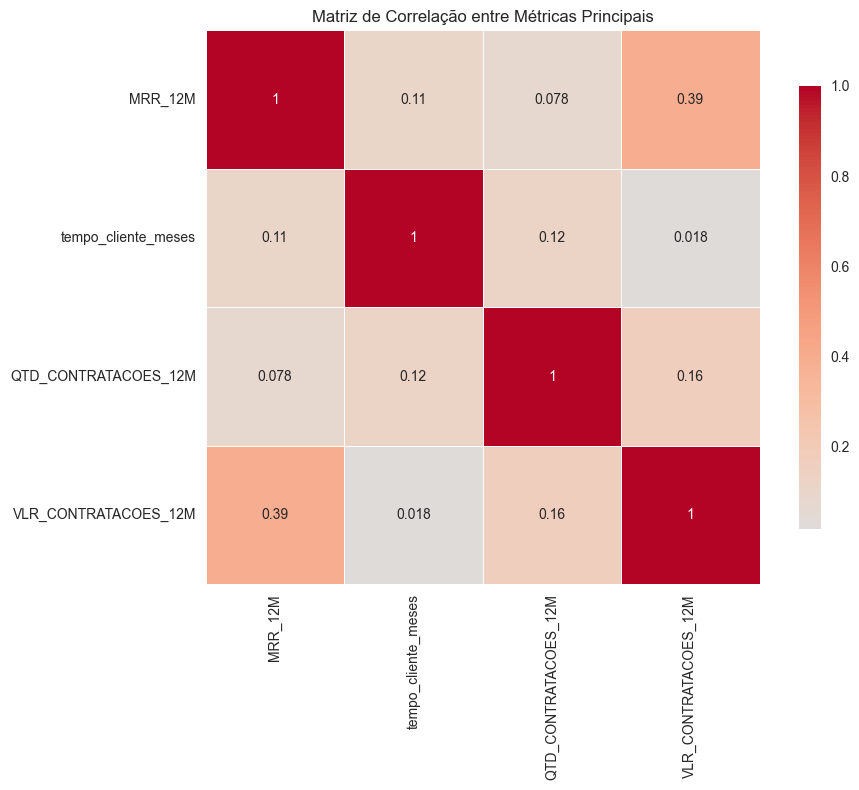


=== INSIGHTS DE CORRELAÇÃO ===
MRR_12M vs tempo_cliente_meses: 0.108
MRR_12M vs QTD_CONTRATACOES_12M: 0.078
MRR_12M vs VLR_CONTRATACOES_12M: 0.391
tempo_cliente_meses vs QTD_CONTRATACOES_12M: 0.125
tempo_cliente_meses vs VLR_CONTRATACOES_12M: 0.018
QTD_CONTRATACOES_12M vs VLR_CONTRATACOES_12M: 0.164


In [17]:
merged_df = mrr_df.merge(clientes_desde_df, left_on='CLIENTE', right_on='CLIENTE', how='inner')
merged_df = merged_df.merge(contratacoes_df, left_on='CLIENTE', right_on='CD_CLIENTE', how='left')

merged_df['CLIENTE_DESDE'] = pd.to_datetime(merged_df['CLIENTE_DESDE'])
merged_df['tempo_cliente_meses'] = ((pd.Timestamp.now() - merged_df['CLIENTE_DESDE']).dt.days / 30).astype(int)

# Converter valores para float antes de calcular
merged_df['VLR_CONTRATACOES_12M'] = merged_df['VLR_CONTRATACOES_12M'].fillna(0)
merged_df['valor_por_contratacao'] = merged_df['VLR_CONTRATACOES_12M'] / merged_df['QTD_CONTRATACOES_12M'].fillna(1)

print("=== ANÁLISE DE CORRELAÇÕES ===")
correlation_vars = ['MRR_12M', 'tempo_cliente_meses', 'QTD_CONTRATACOES_12M', 'VLR_CONTRATACOES_12M']
correlation_matrix = merged_df[correlation_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação entre Métricas Principais')
plt.tight_layout()
plt.show()

print("\n=== INSIGHTS DE CORRELAÇÃO ===")
for i, var1 in enumerate(correlation_vars):
    for j, var2 in enumerate(correlation_vars):
        if i < j:
            corr = correlation_matrix.loc[var1, var2]
            print(f"{var1} vs {var2}: {corr:.3f}")

## 7. Segmentação de Clientes por Valor

=== SEGMENTAÇÃO DE CLIENTES ===


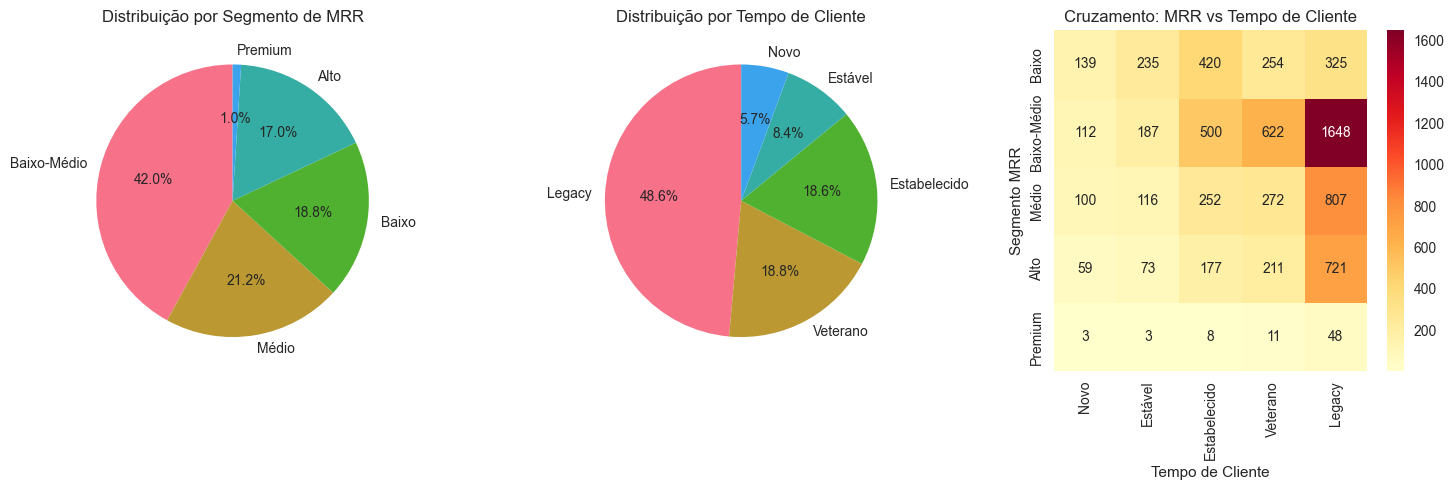


=== INSIGHTS DE SEGMENTAÇÃO ===
Baixo-Médio: 3069 clientes, MRR médio: R$ 262.23
Médio: 1547 clientes, MRR médio: R$ 707.65
Baixo: 1373 clientes, MRR médio: R$ 53.91
Alto: 1241 clientes, MRR médio: R$ 1,831.35
Premium: 73 clientes, MRR médio: R$ 9,660.21


In [18]:
merged_df['segmento_mrr'] = pd.cut(merged_df['MRR_12M'], 
                                    bins=[0, 100, 500, 1000, 5000, float('inf')], 
                                    labels=['Baixo', 'Baixo-Médio', 'Médio', 'Alto', 'Premium'])

merged_df['segmento_tempo'] = pd.cut(merged_df['tempo_cliente_meses'], 
                                      bins=[0, 12, 24, 60, 120, float('inf')], 
                                      labels=['Novo', 'Estável', 'Estabelecido', 'Veterano', 'Legacy'])

print("=== SEGMENTAÇÃO DE CLIENTES ===")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
segmento_mrr_counts = merged_df['segmento_mrr'].value_counts()
plt.pie(segmento_mrr_counts.values, labels=segmento_mrr_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição por Segmento de MRR')

plt.subplot(1, 3, 2)
segmento_tempo_counts = merged_df['segmento_tempo'].value_counts()
plt.pie(segmento_tempo_counts.values, labels=segmento_tempo_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição por Tempo de Cliente')

plt.subplot(1, 3, 3)
cross_segment = pd.crosstab(merged_df['segmento_mrr'], merged_df['segmento_tempo'])
sns.heatmap(cross_segment, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Cruzamento: MRR vs Tempo de Cliente')
plt.xlabel('Tempo de Cliente')
plt.ylabel('Segmento MRR')

plt.tight_layout()
plt.show()

print("\n=== INSIGHTS DE SEGMENTAÇÃO ===")
for segmento in merged_df['segmento_mrr'].unique():
    if pd.notna(segmento):
        segment_data = merged_df[merged_df['segmento_mrr'] == segmento]
        print(f"{segmento}: {len(segment_data)} clientes, MRR médio: R$ {segment_data['MRR_12M'].mean():,.2f}")

## 8. Análise de Tendências Temporais

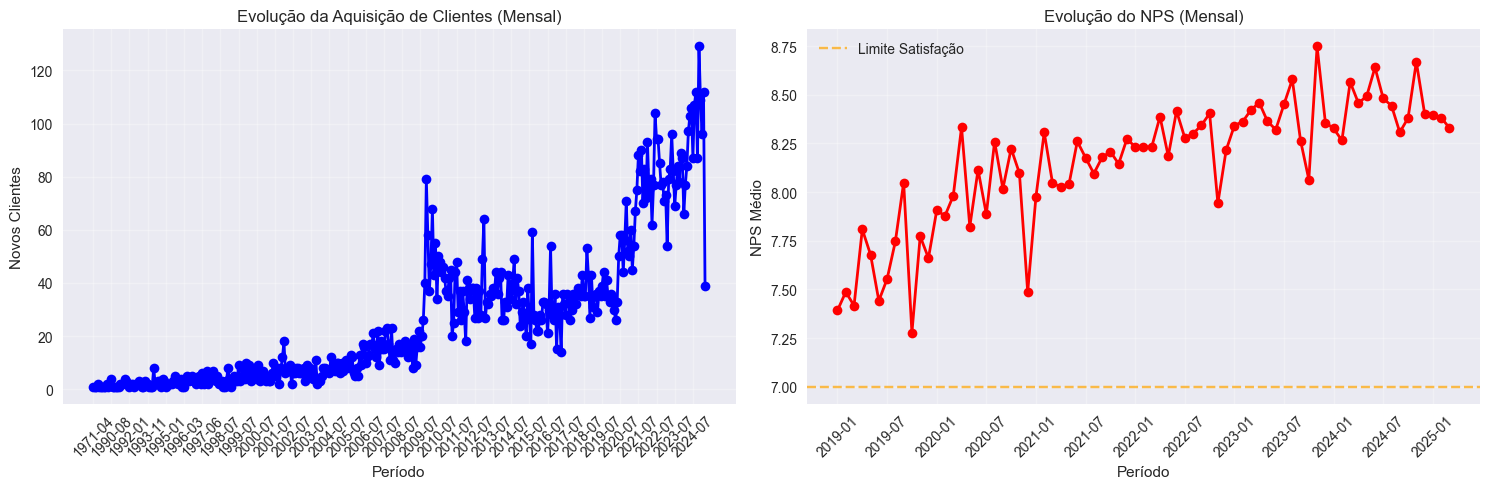

=== INSIGHTS TEMPORAIS ===
Tendência de aquisição: Crescente
Tendência do NPS: Piorando


In [19]:
clientes_desde_df['mes_aquisicao'] = clientes_desde_df['CLIENTE_DESDE'].dt.to_period('M')
aquisicao_mensal = clientes_desde_df.groupby('mes_aquisicao').size().reset_index(name='novos_clientes')
aquisicao_mensal['mes_aquisicao'] = aquisicao_mensal['mes_aquisicao'].astype(str)

nps_relacional_df['mes_avaliacao'] = nps_relacional_df['respondedAt'].dt.to_period('M')
nps_mensal = nps_relacional_df.groupby('mes_avaliacao')['resposta_NPS'].mean().reset_index()
nps_mensal['mes_avaliacao'] = nps_mensal['mes_avaliacao'].astype(str)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(range(len(aquisicao_mensal)), aquisicao_mensal['novos_clientes'], marker='o', linewidth=2, color='blue')
plt.title('Evolução da Aquisição de Clientes (Mensal)')
plt.xlabel('Período')
plt.ylabel('Novos Clientes')
plt.xticks(range(0, len(aquisicao_mensal), 12), aquisicao_mensal['mes_aquisicao'][::12], rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(len(nps_mensal)), nps_mensal['resposta_NPS'], marker='o', linewidth=2, color='red')
plt.title('Evolução do NPS (Mensal)')
plt.xlabel('Período')
plt.ylabel('NPS Médio')
plt.xticks(range(0, len(nps_mensal), 6), nps_mensal['mes_avaliacao'][::6], rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(y=7, color='orange', linestyle='--', alpha=0.7, label='Limite Satisfação')
plt.legend()

plt.tight_layout()
plt.show()

print("=== INSIGHTS TEMPORAIS ===")
print(f"Tendência de aquisição: {'Crescente' if aquisicao_mensal['novos_clientes'].iloc[-12:].mean() > aquisicao_mensal['novos_clientes'].iloc[-24:-12].mean() else 'Decrescente'}")
print(f"Tendência do NPS: {'Melhorando' if nps_mensal['resposta_NPS'].iloc[-6:].mean() > nps_mensal['resposta_NPS'].iloc[-12:-6].mean() else 'Piorando'}")